# **ANALYSIS COVID-19 INDONESIA**

In [1]:
# import modules
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

In [2]:
# load dataset

covid_data = pd.read_csv("covid_19_indonesia_time_series_all.csv")


In [3]:
# set seed for reproducibilty
np.random.seed(0)

In [5]:
#check dataset
covid_data.head()

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20.0,75.0,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20.0,75.0,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0.0,0.0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0.0,1.0,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20.0,75.0,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0


In [8]:
#check missing values
missing_values_count = covid_data.isnull().sum()

#missing values from column 1-10
missing_values_count[0:10]

,0
Date,0
Location ISO Code,0
Location,0
New Cases,0
New Deaths,0
New Recovered,0
New Active Cases,0
Total Cases,0
Total Deaths,1
Total Recovered,1


In [13]:
# Count missing values
total_missing = missing_values_count.sum()
total_cells = np.prod(covid_data.shape)

# Percentage missing balues
percent_missing = (total_missing/total_cells) * 100
print(percent_missing)

6.023106001297336


In [14]:
# Clean missing values
covid_data.dropna()

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths


In [15]:
# Delete all columns with at least one missing value

columns_with_na_dropped = covid_data.dropna(axis=1)
columns_with_na_dropped.head()

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41
2,3/2/2020,IDN,Indonesia,2,0,0,2,2
3,3/2/2020,ID-RI,Riau,1,0,0,1,1
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43


In [17]:
# Check the number of original columns and deleted columns
print("Columns in original dataset: %d \n" % covid_data.shape[1])
print("Columns with na's dropped: %d" % columns_with_na_dropped.shape[1])

Columns in original dataset: 38 

Columns with na's dropped: 8


In [18]:
# Fill in missing data with a value of 0

covid_data.fillna(0)

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20.0,75.0,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,0.00,0.0
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20.0,75.0,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.00,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0.0,0.0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,0.00,0.0
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0.0,1.0,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,0.00,0.0
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20.0,75.0,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4701,8/2/2020,ID-BE,Bengkulu,17,0,0,17,235,19.0,118.0,...,-3.533584,8.50,117.53,0.0,9.50,0.95,8.09%,50.21%,17.00,0.0
4702,8/2/2020,ID-JK,DKI Jakarta,377,0,141,236,22144,852.0,14108.0,...,-6.204699,34.76,2041.65,0.0,78.55,7.86,3.85%,63.71%,1.02,0.0
4703,8/2/2020,ID-YO,Daerah Istimewa Yogyakarta,19,0,10,9,759,21.0,421.0,...,-7.894502,5.23,209.03,0.0,5.78,0.58,2.77%,55.47%,0.28,0.0
4704,8/2/2020,ID-GO,Gorontalo,127,0,61,66,1284,34.0,649.0,...,0.687003,107.57,1087.54,0.0,28.80,2.88,2.65%,50.55%,0.89,0.0


In [19]:
# Fill in missing data values with the values from the next row
covid_data.fillna(method='bfill', axis=0).fillna(0)

/tmp/ipykernel_604/3878637301.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  covid_data.fillna(method='bfill', axis=0).fillna(0)


,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20.0,75.0,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,1.00,1.0
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20.0,75.0,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.00,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0.0,0.0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,1.00,1.0
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0.0,1.0,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,1.00,1.0
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20.0,75.0,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4701,8/2/2020,ID-BE,Bengkulu,17,0,0,17,235,19.0,118.0,...,-3.533584,8.50,117.53,0.0,9.50,0.95,8.09%,50.21%,17.00,0.0
4702,8/2/2020,ID-JK,DKI Jakarta,377,0,141,236,22144,852.0,14108.0,...,-6.204699,34.76,2041.65,0.0,78.55,7.86,3.85%,63.71%,1.02,0.0
4703,8/2/2020,ID-YO,Daerah Istimewa Yogyakarta,19,0,10,9,759,21.0,421.0,...,-7.894502,5.23,209.03,0.0,5.78,0.58,2.77%,55.47%,0.28,0.0
4704,8/2/2020,ID-GO,Gorontalo,127,0,61,66,1284,34.0,649.0,...,0.687003,107.57,1087.54,0.0,28.80,2.88,2.65%,50.55%,0.89,0.0


In [20]:
# Get info from the dataframe
covid_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4706 entries, 0 to 4705
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         4706 non-null   object 
 1   Location ISO Code            4706 non-null   object 
 2   Location                     4706 non-null   object 
 3   New Cases                    4706 non-null   int64  
 4   New Deaths                   4706 non-null   int64  
 5   New Recovered                4706 non-null   int64  
 6   New Active Cases             4706 non-null   int64  
 7   Total Cases                  4706 non-null   int64  
 8   Total Deaths                 4705 non-null   float64
 9   Total Recovered              4705 non-null   float64
 10  Total Active Cases           4705 non-null   float64
 11  Location Level               4705 non-null   object 
 12  City or Regency              0 non-null      float64
 13  Province          

In [22]:
#Find if there's any duplicate data based on id
len(covid_data)-len(covid_data.drop_duplicates())

0

In [23]:
#Examine unique values in column location_iso_code, location, province, population, and population_density
print(covid_data['Location ISO Code'].unique(), "total unique values:", len(covid_data['Location ISO Code'].unique()))
print(covid_data['Location'].unique(), "total unique values:", len(covid_data['Location ISO Code'].unique()))
print(covid_data['Province'].unique(), "total unique values:", len(covid_data['Location ISO Code'].unique()))
print(covid_data['Population'].unique(), "total unique values:", len(covid_data['Location ISO Code'].unique()))
print(covid_data['Population Density'].unique(), "total unique values:", len(covid_data['Location ISO Code'].unique()))

['ID-JK' 'IDN' 'ID-RI' 'ID-JB' 'ID-BT' 'ID-JT' 'ID-SG' 'ID-BA' 'ID-KI'
 'ID-YO' 'ID-SU' 'ID-JI' 'ID-KR' 'ID-SN' 'ID-JA' 'ID-MA' 'ID-PA' 'ID-MU'
 'ID-SS' 'ID-AC' 'ID-KT' 'ID-LA' 'ID-ST' 'ID-SA' 'ID-SB' 'ID-PB' 'ID-KU'
 'ID-SR' 'ID-KB' 'ID-KS' 'ID-BB' 'ID-BE' 'ID-NB' 'ID-NT' 'ID-GO'] total unique values: 35
['DKI Jakarta' 'Indonesia' 'Riau' 'Jawa Barat' 'Banten' 'Jawa Tengah'
 'Sulawesi Tenggara' 'Bali' 'Kalimantan Timur'
 'Daerah Istimewa Yogyakarta' 'Sumatera Utara' 'Jawa Timur'
 'Kepulauan Riau' 'Sulawesi Selatan' 'Jambi' 'Maluku' 'Papua'
 'Maluku Utara' 'Sumatera Selatan' 'Aceh' 'Kalimantan Tengah' 'Lampung'
 'Sulawesi Tengah' 'Sulawesi Utara' 'Sumatera Barat' 'Papua Barat'
 'Kalimantan Utara' 'Sulawesi Barat' 'Kalimantan Barat'
 'Kalimantan Selatan' 'Kepulauan Bangka Belitung' 'Bengkulu'
 'Nusa Tenggara Barat' 'Nusa Tenggara Timur' 'Gorontalo'] total unique values: 35
['DKI Jakarta' nan 'Riau' 'Jawa Barat' 'Banten' 'Jawa Tengah'
 'Sulawesi Tenggara' 'Bali' 'Kalimantan Timur'
 'Daera

In [24]:
# Change datatype from column "date" to datetime64
covid_data['Date'] = pd.to_datetime(covid_data['Date'])

# Examine the dataframe again
covid_data.head()

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,2020-03-01,ID-JK,DKI Jakarta,2,0,0,2,39,20.0,75.0,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,2020-03-02,ID-JK,DKI Jakarta,2,0,0,2,41,20.0,75.0,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0
2,2020-03-02,IDN,Indonesia,2,0,0,2,2,0.0,0.0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,2020-03-02,ID-RI,Riau,1,0,0,1,1,0.0,1.0,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,2020-03-03,ID-JK,DKI Jakarta,2,0,0,2,43,20.0,75.0,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0


In [25]:
# Let's see COVID-19 case growth in Indonesia

date_case = covid_data.groupby(['Date'])[['New Cases']].sum().reset_index()
px.line(x=date_case['Date'],y=date_case['New Cases'], labels={'x': 'Date', 'y':'Total Cases'}, title ='Growth of COVID-19 in Indonesia')

In [26]:
# Now let's see total death cases due to COVID-19 in Indonesia throughout the years

date_death = covid_data.groupby(['Date'])[['New Deaths']].sum().reset_index()
px.line(x=date_death['Date'],y=date_death['New Deaths'], labels={'x': 'Date', 'y':'Total Deaths'}, title ='Total Death Cases of COVID-19 in Indonesia')

In [27]:
#Let's analyze how many total cases, deaths, and recovered in each province

prov = covid_data.groupby(['Province','Population Density'])[['Total Cases', 'Total Recovered', 'Total Deaths']].max().reset_index(). sort_values(['Total Cases'], ascending=False)
prov['Death Percentage'] = (prov['Total Deaths']/prov['Total Cases'])*100
prov['Recovered Percentage'] = (prov['Total Recovered']/prov['Total Cases'])*100
print(prov.shape)
prov

(34, 7)


,Province,Population Density,Total Cases,Total Recovered,Total Deaths,Death Percentage,Recovered Percentage
10,Jawa Timur,846.78,22312,15275.0,2021.0,9.057906,68.460918
4,DKI Jakarta,16334.31,22144,14108.0,852.0,3.847543,63.710260
9,Jawa Tengah,1108.64,12669,7662.0,942.0,7.435472,60.478333
27,Sulawesi Selatan,201.78,9505,6624.0,317.0,3.335087,69.689637
8,Jawa Barat,1276.55,6915,4222.0,217.0,3.138106,61.055676
12,Kalimantan Selatan,103.84,6160,3449.0,294.0,4.772727,55.990260
33,Sumatera Utara,203.82,3962,1495.0,193.0,4.871277,37.733468
1,Bali,729.43,3484,1038.0,21.0,0.602755,29.793341
32,Sumatera Selatan,89.72,3427,1826.0,163.0,4.756347,53.282755
23,Papua,13.60,3087,1380.0,33.0,1.068999,44.703596


/tmp/ipykernel_604/4101005506.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Text(0, 0.5, 'Province')

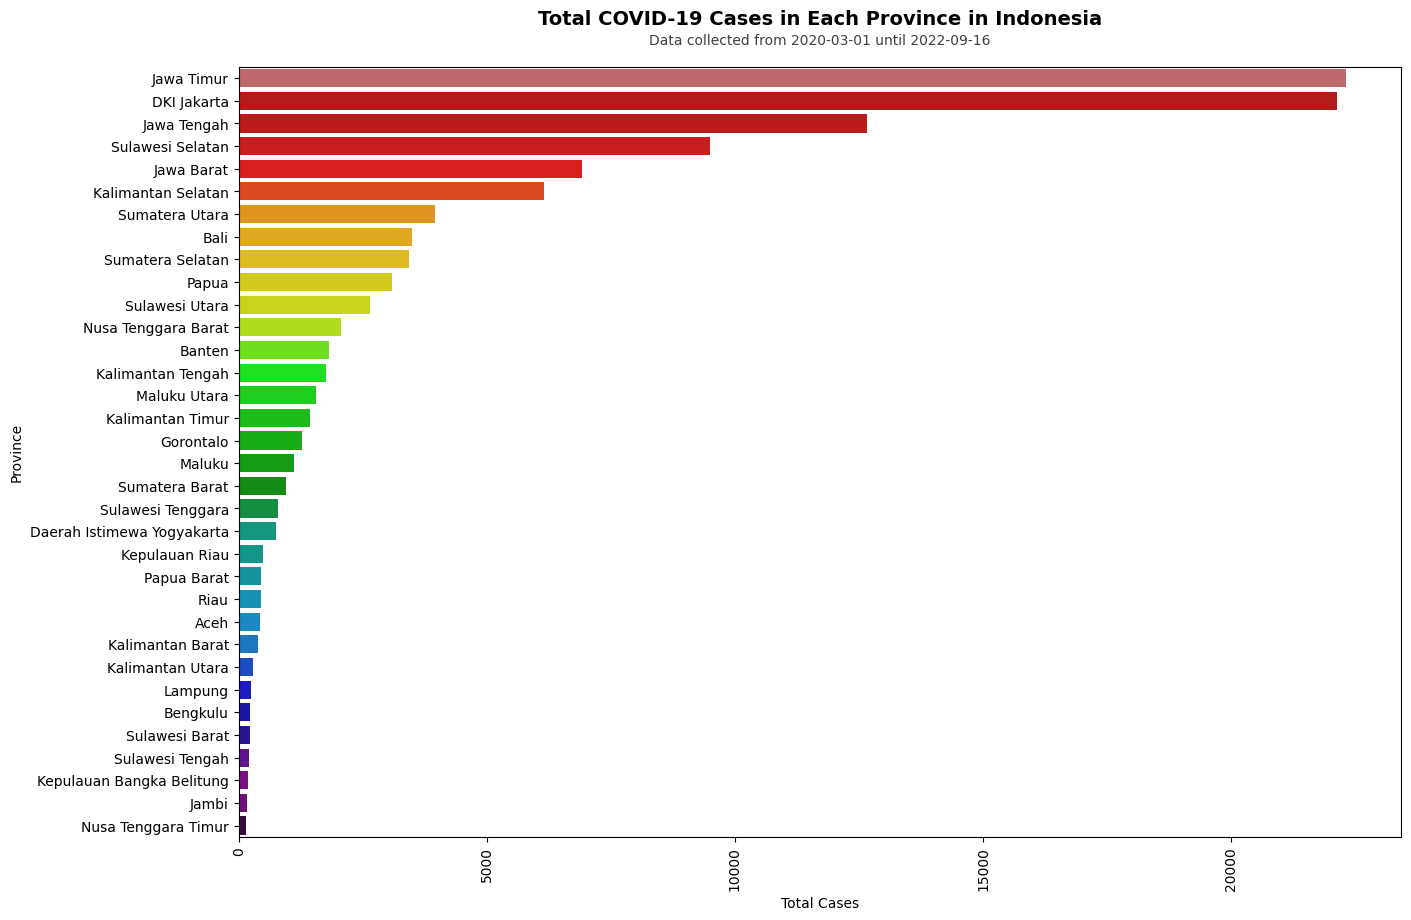

In [32]:
# Visualize the total case in each province

plt.figure(figsize=(15,10),dpi=100)
plt.xticks(rotation=90)
ax = sns.barplot(x=prov['Total Cases'], y=prov['Province'], palette="nipy_spectral_r")
ax.text(x=0.5, y=1.05, s='Total COVID-19 Cases in Each Province in Indonesia', fontsize=14, weight='bold', ha='center', va='bottom', transform=ax.transAxes)
ax.text(x=0.5, y=1.025, s='Data collected from 2020-03-01 until 2022-09-16', fontsize=10, alpha=0.75, ha='center', va='bottom', transform=ax.transAxes)
plt.xlabel('Total Cases')
plt.ylabel('Province')

/tmp/ipykernel_604/3493877595.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 0, 'Total Recovered')

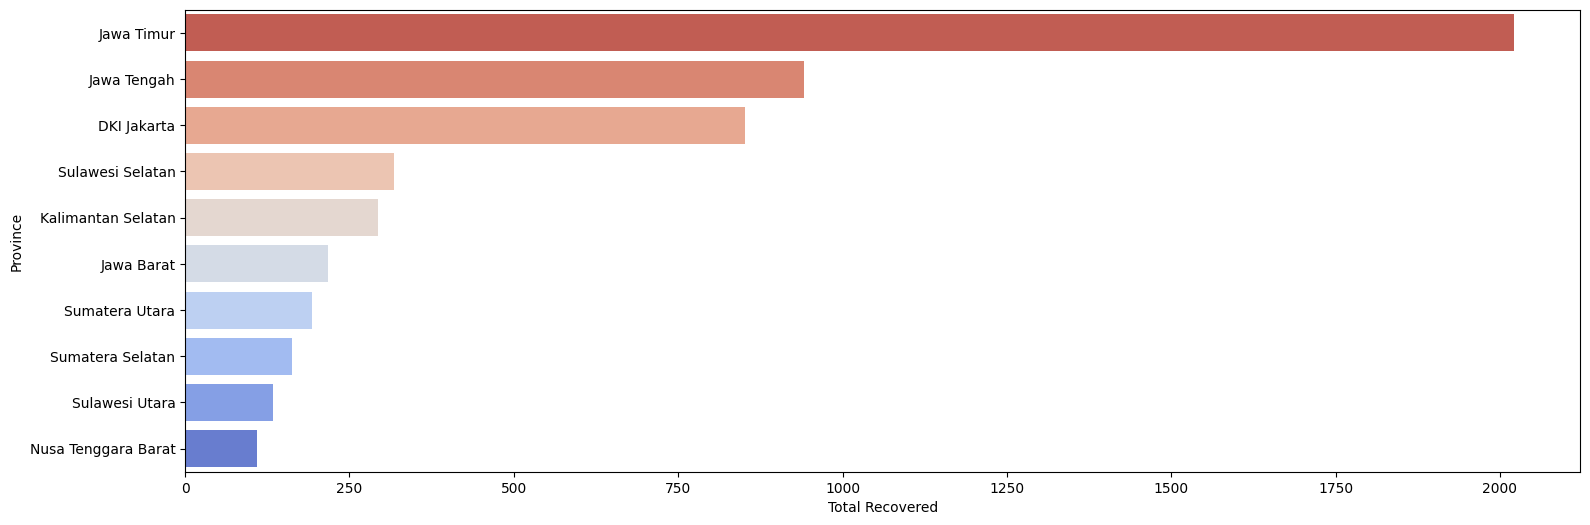

In [33]:
#Let's see the province with the most total deaths

top_10_deaths = prov.sort_values('Total Deaths', ascending=False).head(10)
plt.figure(figsize=(18,6), dpi=100)
sns.barplot(x=top_10_deaths['Total Deaths'],y=top_10_deaths['Province'], palette='coolwarm_r')
plt.ylabel('Province')
plt.xlabel('Total Recovered')

/tmp/ipykernel_604/2422806102.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 0, 'Province')

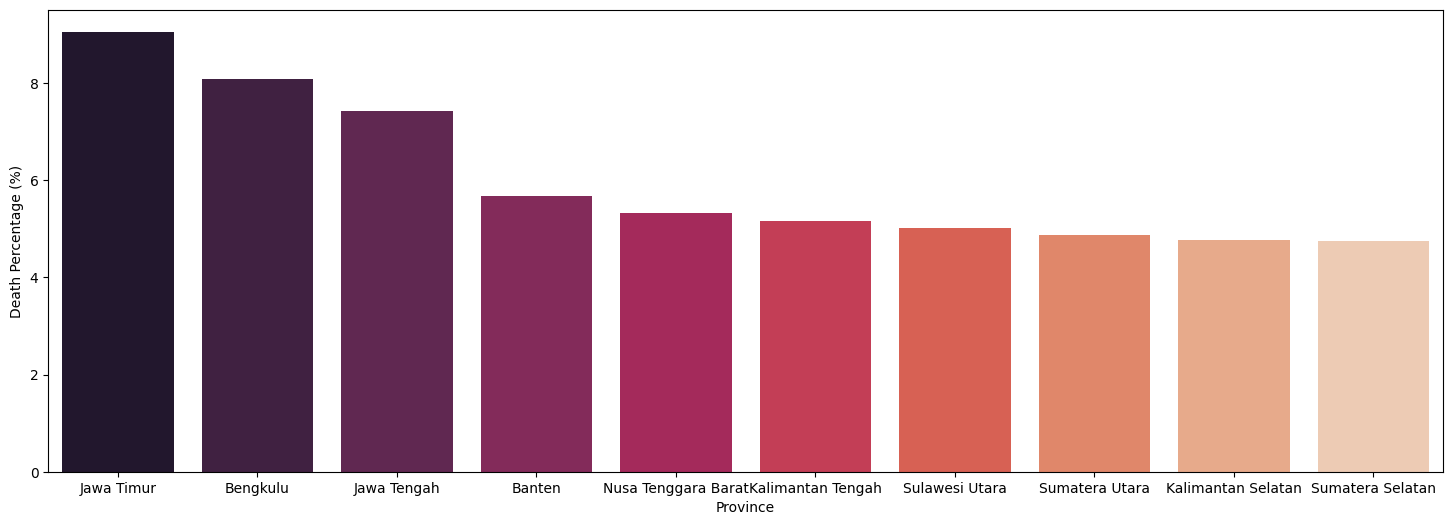

In [34]:
#Let's see the province with the highest death percentage

top_10_dp= prov.sort_values('Death Percentage', ascending=False).head(10)
plt.figure(figsize=(18,6), dpi=100)
sns.barplot(y=top_10_dp['Death Percentage'],x=top_10_dp['Province'], palette='rocket')
plt.ylabel('Death Percentage (%)')
plt.xlabel('Province')

/tmp/ipykernel_604/1650520189.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 0, 'Total Recovered')

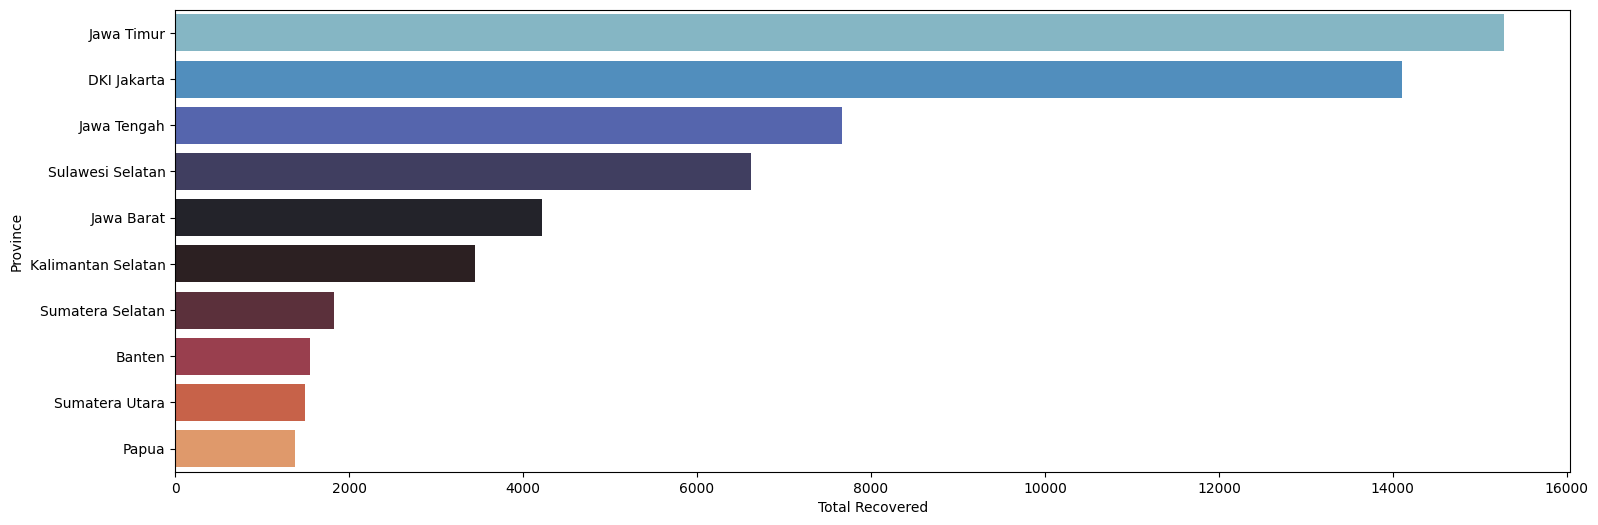

In [35]:
#Let's see the province with the most total recovered cases

top_10_rec = prov.sort_values('Total Recovered', ascending=False).head(10)
plt.figure(figsize=(18,6), dpi=100)
sns.barplot(x=top_10_rec['Total Recovered'],y=top_10_rec['Province'], palette='icefire')
plt.ylabel('Province')
plt.xlabel('Total Recovered')

`Conclusion:`

- `The highest number of COVID-19 cases in Indonesia was recorded on July 9, 2020, with 5,268 cases`
- `The highest number of COVID-19 deaths in Indonesia occurred on July 22, 2020, with 273 deaths`
- `The province with the highest number of COVID-19 cases and deaths is East Java`
- `East Java is also the province with the highest number of recoveries in Indonesia`


**Thanks for the attention :)**